In [1]:
import re
import os
import ast
import numpy as np
import pandas as pd
from tqdm import tqdm
from datasets import load_dataset
from matplotlib import pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
ds = load_dataset("LabARSS/MMLU-Pro-reasoning-entropy-Qwen3-8B")

In [3]:
df = pd.DataFrame(ds["train"])
df

,answer,answer_index,base_cluster,category,cot_content,meta_cluster,options,question,question_id,qwen_8b_ans_correct,...,qwen_8b_answer_embeddings,qwen_8b_entropies,qwen_8b_every_token_info,qwen_8b_extracted_answer_text,qwen_8b_input_embeddings,qwen_8b_response,qwen_8b_think_embeddings,src,total_tokens,__index_level_0__
0,C,2,Legal Theory Interpretations,law,None,Legal Interpretation,[There is no distinction between the two forms...,Which of the following criticisms of Llewellyn...,1286,True,...,"{""min"": [1.1953125, 0.359375, 0.6796875, -0.41...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[[{""token_idx"": 151667, ""token_prob"": 1.0}], [...",3,"{""min"": [-1.8671875, -4.375, -3.015625, -2.312...","<think>\nOkay, let's tackle this question. The...","{""min"": [-2.6875, -4.03125, -5.125, -4.40625, ...",ori_mmlu-jurisprudence,81,0
1,E,4,Constitutional Law,law,None,Legal Interpretation,"[Article 19, Article 11, Article 12, Article 9...",Which of the following articles are not qualif...,1293,True,...,"{""min"": [1.0546875, 0.423828125, 0.57421875, -...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.7254042...","[[{""token_idx"": 151667, ""token_prob"": 1.0}], [...",5,"{""min"": [-1.65625, -4.0, -2.984375, -3.765625,...","<think>\nOkay, let's tackle this question. The...","{""min"": [-4.78125, -4.03125, -4.0625, -6.34375...",ori_mmlu-international_law,38,1
2,D,3,Business & Marketing Queries,business,None,Economics & Finance MCQs,"[Work delegation, Workload balancing, Work dis...",As what is ensuring that one individual does n...,83,False,...,"{""min"": [1.140625, 0.353515625, 0.65234375, -0...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[[{""token_idx"": 151667, ""token_prob"": 1.0}], [...",2,"{""min"": [-1.78125, -5.53125, -3.390625, -2.437...","<think>\nOkay, let's tackle this question. The...","{""min"": [-1.625, -4.125, -3.015625, -2.5625, -...",ori_mmlu-management,49,2
3,J,9,Business Finance Questions,business,None,Economics & Finance MCQs,"[$308.25, $142.75, $199.99, $225.85, $113.52, ...",Margaret Denault recently rented a truck to dr...,94,False,...,,"[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[[{""token_idx"": 151667, ""token_prob"": 1.0}], [...",None,"{""min"": [-2.046875, -5.625, -3.03125, -2.34375...","<think>\nOkay, let's see. Margaret rented a tr...",,stemez-Business,118,3
4,I,8,Business Finance Questions,business,None,Economics & Finance MCQs,"[$60,000, $43,200, $1,794, $25,000, $30,000, $...",The tax rate in the town of Centerville is 11(...,104,True,...,"{""min"": [1.03125, -0.0198974609375, 0.75390625...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[[{""token_idx"": 151667, ""token_prob"": 1.0}], [...",9,"{""min"": [-1.671875, -4.53125, -3.421875, -3.40...","<think>\nOkay, let's see. The question is abou...","{""min"": [-2.78125, -4.03125, -4.40625, -3.7031...",stemez-Business,102,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12027,F,5,Economic Concepts & Policies,economics,None,Economics & Finance MCQs,[Higher interest rates that result from borrow...,"The ""crowding-out"" effect refers to which of t...",7681,True,...,"{""min"": [1.0234375, 0.359375, 0.5546875, -0.36...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[[{""token_idx"": 151667, ""token_prob"": 1.0}], [...",6,"{""min"": [-1.7109375, -4.34375, -3.296875, -3.0...","<think>\nOkay, let's tackle this question abou...","{""min"": [-5.53125, -4.03125, -3.9375, -4.59375...",ori_mmlu-high_school_macroeconomics,150,12027
12028,A,0,Economic Concepts & Policies,economics,None,Economics & Finance MCQs,[Lower reserve requirements; lower the discoun...,Which of the following lists contains only Fed...,7683,True,...,"{""min"": [1.1796875, 0.17578125, 0.84375, -0.58...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.5303041...","[[{""token_idx"": 151667, ""token_prob"": 1.0}], [...",1,"{""min"": [-2.5, -4.0625, -3.28125, -3.6875, -5....","<think>\nOkay, let's tackle this question. The...","

In [4]:
def extract_answer_last_integer(text):
    splitted_texts = text.split("</think>")
    if len(splitted_texts) != 2:
        return 100
    answer_text = splitted_texts[-1]
    matches = re.findall(r"[1-9]", answer_text)
    return (int(matches[-1]) - 1) if matches else 100

In [5]:
df["qwen_8b_response_index"] = df["qwen_8b_response"].apply(extract_answer_last_integer)
df["is_correct"] = (df["answer_index"] == df["qwen_8b_response_index"])

In [6]:
print("Accuracy:", df.is_correct.sum() / df.answer_index.shape[0])

Accuracy: 0.5953291223404256


In [7]:
qwen_8b_every_token_info_converted = list()
for idx in tqdm(range(df.shape[0])):
    qwen_8b_every_token_info_converted.append(
        ast.literal_eval(df.qwen_8b_every_token_info.iloc[idx])
    )


00%|█████████████████████████████████████| 12032/12032 [11:06<00:00, 18.05it/s]

In [18]:
def get_generation_statistics(every_token_info):
    
    think_token_idx = 151668
    special_token_treshold = 151642

    def get_generated_token_idx(gen_token_info):
        return max(gen_token_info, key=lambda y: y["token_prob"])["token_idx"]

    def calculate_entropy(prob_list):
        prob_np = np.array(prob_list)
        return - (prob_np * np.log(prob_np)).sum()
        
    genertaed_tokens_list = list(map(get_generated_token_idx, every_token_info))

    if not genertaed_tokens_list.count(think_token_idx):
        return {
            "thinking_length": float("inf"),
            "thinking_sum_entropy": float("inf"),
            "thinking_nonzero_entropy_length": float("inf"),
            "answer_length": None,
            "answer_sum_entropy": None,
            "answer_nonzero_entropy_length": None,
        }

    elif genertaed_tokens_list.count(think_token_idx) == 1:
    
        think_token_place = genertaed_tokens_list.index(think_token_idx)
        thinking_text_places = [
            idx for idx in range(think_token_place)
            if genertaed_tokens_list[idx] <= special_token_treshold
        ]
        answer_text_places = [
            idx for idx in range(think_token_place + 1, len(genertaed_tokens_list))
            if genertaed_tokens_list[idx] <= special_token_treshold
        ]
    
        think_token_every_token_info = [every_token_info[idx] for idx in thinking_text_places]
        answer_token_every_token_info = [every_token_info[idx] for idx in answer_text_places]
    
        thinking_length = len(thinking_text_places)
        thinking_nonzero_entropy_length = sum(map(lambda x: len(x) != 1, think_token_every_token_info))
        thinking_sum_entropy = 0.
        thinking_nonzero_entropy_length = 0
        for think_token_info in think_token_every_token_info:
            if len(think_token_info) > 1:
                think_token_probs = [info["token_prob"] for info in think_token_info]
                thinking_sum_entropy += calculate_entropy(think_token_probs)
                thinking_nonzero_entropy_length += 1
                # print(calculate_entropy(think_token_probs))
    
        answer_length = len(answer_text_places)
        answer_nonzero_entropy_length = sum(map(lambda x: len(x) != 1, answer_token_every_token_info))
        answer_sum_entropy = 0.
        answer_nonzero_entropy_length = 0
        for answer_token_info in answer_token_every_token_info:
            if len(answer_token_info) > 1:
                answer_token_probs = [info["token_prob"] for info in answer_token_info]
                answer_sum_entropy += calculate_entropy(answer_token_probs)
                answer_nonzero_entropy_length += 1
    
        return {
            "thinking_length": thinking_length,
            "thinking_sum_entropy": np.array(thinking_sum_entropy).item(),
            "thinking_nonzero_entropy_length": thinking_nonzero_entropy_length,
            "answer_length": answer_length,
            "answer_sum_entropy": answer_sum_entropy,
            "answer_nonzero_entropy_length": answer_nonzero_entropy_length,
        }

    else:
        # raise ValueError
        return {
            "thinking_length": float("inf"),
            "thinking_sum_entropy": float("inf"),
            "thinking_nonzero_entropy_length": float("inf"),
            "answer_length": None,
            "answer_sum_entropy": None,
            "answer_nonzero_entropy_length": None,
        }

In [19]:
get_generation_statistics(qwen_8b_every_token_info_converted[5])

{'thinking_length': inf,
 'thinking_sum_entropy': inf,
 'thinking_nonzero_entropy_length': inf,
 'answer_length': None,
 'answer_sum_entropy': None,
 'answer_nonzero_entropy_length': None}

In [20]:
generation_statistics_list = list()
for every_token_info_converted in qwen_8b_every_token_info_converted:
    # try:
    #     get_generation_statistics(every_token_info_converted)
    # except:
    #     print(i, df.iloc[i].qwen_8b_response)
    generation_statistics_list.append(
        get_generation_statistics(every_token_info_converted)
    )

In [21]:
df_generation_statistics = pd.DataFrame(generation_statistics_list)
df_generation_statistics

,thinking_length,thinking_sum_entropy,thinking_nonzero_entropy_length,answer_length,answer_sum_entropy,answer_nonzero_entropy_length
0,613.0,21.390227,47.0,2.0,0.0,0.0
1,2045.0,72.256952,150.0,2.0,0.0,0.0
2,437.0,12.788861,34.0,2.0,0.0,0.0
3,inf,inf,inf,NaN,NaN,NaN
4,1505.0,17.596851,42.0,2.0,0.0,0.0
...,...,...,...,...,...,...
12027,881.0,21.995526,50.0,2.0,0.0,0.0
12028,552.0,13.864292,32.0,2.0,0.0,0.0
12029,1674.0,40.751844,94.0,2.0,0.0,0.0
12030,543.0,9.157031,20.0,2.0,0.0,0.0


In [24]:
df_stats = pd.concat([df, df_generation_statistics], axis=1).dropna(subset="answer_length").reset_index(drop=True)
df_stats

,answer,answer_index,base_cluster,category,cot_content,meta_cluster,options,question,question_id,qwen_8b_ans_correct,...,total_tokens,__index_level_0__,qwen_8b_response_index,is_correct,thinking_length,thinking_sum_entropy,thinking_nonzero_entropy_length,answer_length,answer_sum_entropy,answer_nonzero_entropy_length
0,C,2,Legal Theory Interpretations,law,None,Legal Interpretation,[There is no distinction between the two forms...,Which of the following criticisms of Llewellyn...,1286,True,...,81,0,2,True,613.0,21.390227,47.0,2.0,0.0,0.0
1,E,4,Constitutional Law,law,None,Legal Interpretation,"[Article 19, Article 11, Article 12, Article 9...",Which of the following articles are not qualif...,1293,True,...,38,1,4,True,2045.0,72.256952,150.0,2.0,0.0,0.0
2,D,3,Business & Marketing Queries,business,None,Economics & Finance MCQs,"[Work delegation, Workload balancing, Work dis...",As what is ensuring that one individual does n...,83,False,...,49,2,1,False,437.0,12.788861,34.0,2.0,0.0,0.0
3,I,8,Business Finance Questions,business,None,Economics & Finance MCQs,"[$60,000, $43,200, $1,794, $25,000, $30,000, $...",The tax rate in the town of Centerville is 11(...,104,True,...,102,4,8,True,1505.0,17.596851,42.0,2.0,0.0,0.0
4,I,8,Business Finance Questions,business,None,Economics & Finance MCQs,"[500%, 700%, 646%, 65%, 60%, 800%, 845%, 75%, ...",What percent of .65% is .42%?,143,True,...,40,6,8,True,1739.0,30.041735,70.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10217,F,5,Economic Concepts & Policies,economics,None,Economics & Finance MCQs,[Higher interest rates that result from borrow...,"The ""crowding-out"" effect refers to which of t...",7681,True,...,150,12027,5,True,881.0,21.995526,50.0,2.0,0.0,0.0
10218,A,0,Economic Concepts & Policies,economics,None,Economics & Finance MCQs,[Lower reserve requirements; lower the discoun...,Which of the following lists contains only Fed...,7683,True,...,124,12028,0,True,552.0,13.864292,32.0,2.0,0.0,0.0
10219,I,8,Economic Concepts & Policies,economics,None,Economics & Finance MCQs,[The productivity of labor in country X is 75 ...,Output in country X is 30000 units and there a...,7684,True,...,206,12029,8,True,1674.0,40.751844,94.0,2.0,0.0,0.0
10220,B,1,Economic Concepts & Policies,economics,None,Economics & Finance MCQs,"[an increase in net exports, a decrease in net...",A use of easy money (expansionary) policy by t...,7685,False,...,58,12030,0,False,543.0,9.157031,20.0,2.0,0.0,0.0


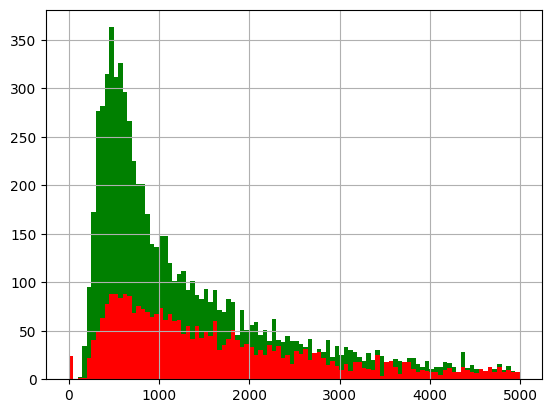

In [32]:
# df_stats.thinking_length.hist(bins=100)
df_stats[df_stats.is_correct].thinking_length.hist(bins=100, color="green")
df_stats[~df_stats.is_correct].thinking_length.hist(bins=100, color="red")
plt.show()

Если отбрасывать долгие размышления, то кач-во растет.

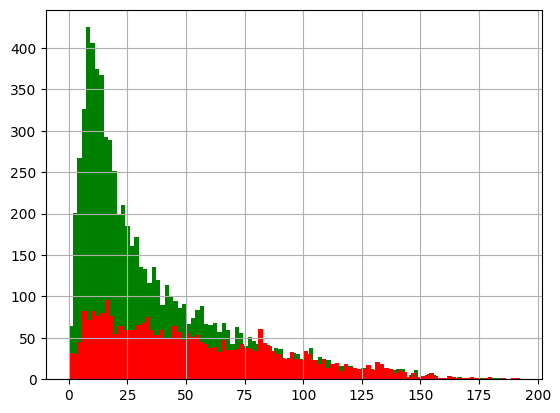

In [36]:
# df_stats.thinking_length.hist(bins=100)
df_stats[df_stats.is_correct].thinking_sum_entropy.hist(bins=100, color="green")
df_stats[~df_stats.is_correct].thinking_sum_entropy.hist(bins=100, color="red")
plt.show()

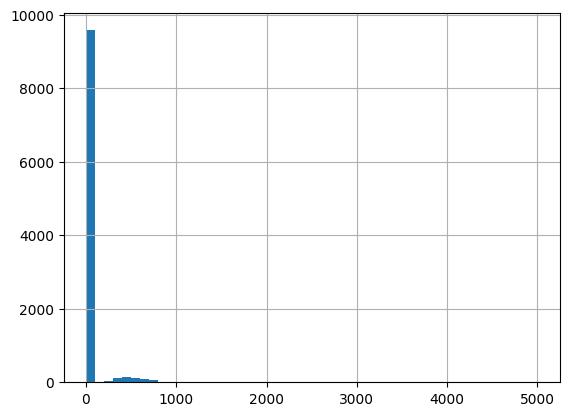

In [41]:
df_stats.answer_length.hist(bins=50)
plt.show()

In [47]:
# # df_stats[df_stats.answer_length!=2].answer_length.hist(bins=50)
# # plt.show()

# # df_stats.thinking_length.hist(bins=100)
# df_stats[df_stats.answer_length!=2][df_stats.is_correct].thinking_sum_entropy.hist(bins=10, color="green")
# # df_stats[df_stats.answer_length!=2][~df_stats.is_correct].thinking_sum_entropy.hist(bins=10, color="red")
# plt.show()